## Предисловие


Все что связано с алгоритмами непривычные для меня сценарии.

В работе они мне не встречаются, а отдельно я их не тренил. 

По этому честно написал где решал с помощью чат бота.

------------

## Задача №1. 

Напишите реализацию быстрой сортировки массива чисел с использованием рекурсии. Добавьте функциональность измерения производительности вашей реализации, используя модуль `timeit`.

### Решение

Метод быстрой сортировки ни разу не писал. Задание выполнено через чат-бот.

Сам алгоритм работы понятен.

In [37]:
import timeit
import random

# Быстрая сортировка
def quicksort(arr):
    """
    На вход принимаем массив
    """
    # Если массив пустой или из одного элемента - он уже отсортирован
    if len(arr) <= 1:
        return arr
    
    # Выбираем опорный элемент (первый элемент массива)
    pivot = arr[0]
    
    # Создаем три списка:
    left = []    # элементы меньше опорного
    middle = []  # элементы равные опорному
    right = []   # элементы больше опорного
    
    # Распределяем элементы по спискам
    for x in arr:
        if x < pivot:
            left.append(x)
        elif x == pivot:
            middle.append(x)
        else:
            right.append(x)
    
    # Рекурсивно сортируем левую и правую части и объединяем результаты
    return quicksort(left) + middle + quicksort(right)

In [38]:
# Тестируем работу алгоритма

print("=" * 50)
print("ТЕСТ 1: Проверка работы на маленьком массиве")
print("=" * 50)

# Создаем тестовый массив
test_array = [5, 2, 8, 1, 9, 3, 7, 4, 6]
print(f"Исходный массив: {test_array}")

# Сортируем
sorted_array = quicksort(test_array)
print(f"Отсортированный массив: {sorted_array}")
print(f"Правильно? {sorted_array == sorted(test_array)}")

ТЕСТ 1: Проверка работы на маленьком массиве
Исходный массив: [5, 2, 8, 1, 9, 3, 7, 4, 6]
Отсортированный массив: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Правильно? True


In [39]:
# Измерение производительности

print("\n" + "=" * 50)
print("ТЕСТ 2: Сравнение с встроенной сортировкой")
print("=" * 50)

# Создаем случайный массив из 1000 элементов
random_array = [random.randint(1, 1000) for _ in range(1000)]

# Измеряем время нашей сортировки
start_time = timeit.default_timer()
our_sort_result = quicksort(random_array)
our_sort_time = timeit.default_timer() - start_time

# Измеряем время встроенной сортировки Python
start_time = timeit.default_timer()
python_sort_result = sorted(random_array)
python_sort_time = timeit.default_timer() - start_time

print(f"Наша сортировка:      {our_sort_time:.6f} секунд")
print(f"Сортировка Python:    {python_sort_time:.6f} секунд")
print(f"Результаты совпадают: {our_sort_result == python_sort_result}")


ТЕСТ 2: Сравнение с встроенной сортировкой
Наша сортировка:      0.000738 секунд
Сортировка Python:    0.000095 секунд
Результаты совпадают: True


## Задача №2. 

Вы работаете с файлом большого размера (~1 ГБ). Напишите скрипт для обработки файла построчно и посчитайте количество строк, содержащих определенный паттерн текста («data»), учитывая исключения при открытии файла и обработку ошибок чтения.

### Решение

Самое простое прочитать файл построчно с помощью контекстного менеджера и использовать `try...except` для обработки ошибок.

In [17]:
# Пример файла
with open("test_file.txt", "r", encoding="utf-8") as f:
    print(f.read())

Первая строка
Здесь data встречается первый раз
Обычная строка 
data появляется здесь
data data data
строка без паттерна
Еще одна строка с data
data в начале строки
Завершающая строка без паттерна
И финальная data строка


In [18]:
def count_pattern(file_path, pattern="data"):
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            return sum(1 for line in f if pattern in line)
    except Exception as e:
        print(f"Ошибка: {e}")
        return 0

count = count_pattern("test_file.txt", "data")
print(f"Найдено строк с 'data': {count}")

Найдено строк с 'data': 6


## Задача №3. 

Представьте массив случайных чисел длиной миллион элементов. Создайте генератор, который позволяет получать числа по одному элементу за раз, таким образом экономя память.

### Решение

Я хорошо знаком с генератором списков `[x for x in range(5)]` но не знал что есть генератор генераторов.

По сути отличается только скобками `(x for x in range(5))`, потом вызываем по одному элементу.

In [31]:
import random

gen = (random.random() for x in range(1_000_000))

# Получаем числа по одному с помощью next
print("Первые 3 числа из генератора:")
for i in range(3):
    print(next(gen)) 

Первые 3 числа из генератора:
0.3954111900129369
0.4914930648758128
0.09052927941343614


## Задача №4. 

Используя pandas, рассчитайте среднее значение всех столбцов числового типа и максимальное значение каждого категориального столбца в датасете, содержащем продажи товаров по регионам.

### Решение

Не совсем понимаю, что имеется под `"максимальное значение каждого категориального столбца"`. Максимальное значение упоминаний?

Чтобы найти все интересующие нас параметры используем функцию `describe()` Она удобно выведет всю нужную нам информацию и даже чуть больше.

По умолчанию она работает с числовыми полями, но если очень попросить выведет данные и про категориальные

In [40]:
import pandas as pd
import numpy as np

# Сгенерим датасет
df = pd.DataFrame({
    'Регион':  np.random.choice(['Москва', 'СПб', 'Казань', 'Екб', 'Нск'], 100),
    'Товар':   np.random.choice(['Ноутбук', 'Смартфон', 'Планшет'], 100),
    'Продажи': np.random.randint(1, 50, 100),
    'Цена':    np.random.randint(5000, 100000, 100),
    'Скидка':  np.random.choice([0, 5, 10, 15], 100)
})

print("\nИсходный датасет")
display(df.head())

# Поделим столбцы на категориальные и числовые
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Числовые столбцы:       {list(numeric_cols)}")
print(f"Категориальные столбцы: {list(categorical_cols)}\n")

print("Интересующая нас строка: mean (среднее значение по полю)")
print(df[numeric_cols].describe())

print("\n\nИнтересующая нас строки: top (Наиболее упоминаемое значение)")
print("                         freq (Количество упоминаний)")
print(df[categorical_cols].describe())


Исходный датасет


,Регион,Товар,Продажи,Цена,Скидка
0,Казань,Ноутбук,18,47845,15
1,Екб,Планшет,16,80851,10
2,Нск,Планшет,15,17834,0
3,Екб,Планшет,48,72850,5
4,Москва,Планшет,8,42180,0


Числовые столбцы:       ['Продажи', 'Цена', 'Скидка']
Категориальные столбцы: ['Регион', 'Товар']

Интересующая нас строка: mean (среднее значение по полю)
          Продажи          Цена      Скидка
count  100.000000    100.000000  100.000000
mean    25.880000  50731.410000    7.500000
std     14.217843  27695.482305    5.838742
min      1.000000   5427.000000    0.000000
25%     13.000000  27784.000000    0.000000
50%     27.000000  50176.500000   10.000000
75%     37.500000  74446.500000   10.000000
max     49.000000  99910.000000   15.000000


Интересующая нас строки: top (Наиболее упоминаемое значение)
                         freq (Количество упоминаний)
       Регион    Товар
count     100      100
unique      5        3
top       Нск  Ноутбук
freq       29       34


## Задача №5. 

Создайте два двумерных массива размером 10×10 и вычислите сумму соответствующих элементов матриц. Затем найдите максимальный элемент полученной суммы.

### Решение

Матрицы проходил на курсе по Data Science, был спринт по линейной алгебре. 

Там разное с ними делали, складывали, вычитали, умножали на вектор, транспонировали и т.п.

In [100]:
import numpy as np

# Создаем два двумерных массива 10×10 со случайными числами
matrix1 = np.random.randint(0, 6, size=(10, 10))
matrix2 = np.random.randint(0, 6, size=(10, 10))

# Вычисляем сумму соответствующих элементов
sum_matrix = matrix1 + matrix2

# Находим максимальный элемент
max_element = np.max(sum_matrix)

# Вывод результатов
print("Матрица 1:")
print(matrix1)

print("\nМатрица 2:")
print(matrix2)

print("\nСумма матриц:")
print(sum_matrix)

print(f"\nМаксимальный элемент суммы: {max_element}")

Матрица 1:
[[1 2 3 2 4 0 3 3 4 2]
 [0 2 1 2 3 0 2 0 0 1]
 [1 3 4 0 4 3 0 0 5 4]
 [2 1 2 4 1 2 5 1 0 2]
 [1 5 1 1 5 2 3 2 4 5]
 [2 1 5 0 2 5 2 5 1 0]
 [0 4 5 2 0 0 3 3 0 5]
 [4 0 1 2 4 1 4 1 2 2]
 [3 5 1 3 1 3 2 4 3 1]
 [1 5 2 1 0 4 3 5 4 2]]

Матрица 2:
[[5 3 3 0 2 5 5 1 0 0]
 [5 5 4 4 4 0 1 3 4 1]
 [2 4 3 2 2 3 4 0 3 3]
 [3 2 1 0 4 4 1 3 0 4]
 [5 4 3 5 1 0 1 1 0 0]
 [4 4 0 5 2 4 2 5 0 5]
 [4 1 0 3 2 5 0 5 0 4]
 [4 4 5 3 4 0 4 1 4 5]
 [3 1 5 5 5 0 5 0 5 2]
 [1 2 5 1 1 3 2 3 1 0]]

Сумма матриц:
[[ 6  5  6  2  6  5  8  4  4  2]
 [ 5  7  5  6  7  0  3  3  4  2]
 [ 3  7  7  2  6  6  4  0  8  7]
 [ 5  3  3  4  5  6  6  4  0  6]
 [ 6  9  4  6  6  2  4  3  4  5]
 [ 6  5  5  5  4  9  4 10  1  5]
 [ 4  5  5  5  2  5  3  8  0  9]
 [ 8  4  6  5  8  1  8  2  6  7]
 [ 6  6  6  8  6  3  7  4  8  3]
 [ 2  7  7  2  1  7  5  8  5  2]]

Максимальный элемент суммы: 10


## Задача №6. 

Имеются временные ряды ежедневных продаж продукта за последний год. Вычислите скользящее среднее за неделю и визуализируйте изменения среднего значения.

### Решение

Тут все знакомо.

С временными рядами был спринт на курсе Data Science. Даже строили модель на временных рядах.

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')
sales = np.random.randint(50, 200, size=len(dates))

# Создадим датафрейм
df = pd.DataFrame({
    'date': dates,
    'sales': sales
})

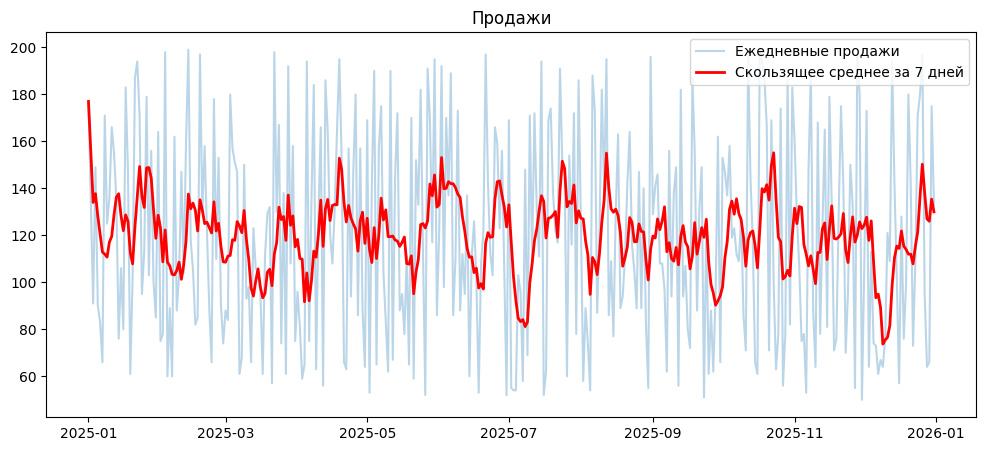

In [73]:
df['rolling_7d'] = df['sales'].rolling(7, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['sales'], alpha=0.3, label='Ежедневные продажи')
plt.plot(df['date'], df['rolling_7d'], 'r-', linewidth=2, label='Скользящее среднее за 7 дней')
plt.legend()
plt.title('Продажи')
plt.show()

## Задача №7. 

Получив сложный JSON-файл с многоуровневой структурой, извлеките вложенный список значений определенного ключа ("price") и отсортируйте этот список по возрастанию.

### Решение

Руками я такой парсер с ходу не напишу. Есть удобная библиотека `jsonpath_ng`

In [5]:
import json

# Для начала прочитаем заранее заготовленый файл
with open('data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

print(json.dumps(data, indent=2))

{
  "store": {
    "items": [
      {
        "id": 1,
        "price": 100
      },
      {
        "id": 2,
        "price": 50
      }
    ]
  },
  "cart": {
    "total": 150,
    "products": [
      {
        "price": 100
      },
      {
        "price": 50
      }
    ]
  },
  "sale": {
    "price": 75
  }
}


In [6]:
from jsonpath_ng import parse

with open('data.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# Запустим парсер по ключу price
prices = [match.value for match in parse('$..price').find(data)]
sorted_prices = sorted(prices)

print(f"Найдено значений price: {len(sorted_prices)}")
print(f"Исходные:        {prices}")
print(f"Отсортированные: {sorted_prices}")

Найдено значений price: 5
Исходные:        [100, 50, 100, 50, 75]
Отсортированные: [50, 50, 75, 100, 100]


## Задача №8. 

Используйте многопоточность для одновременного вычисления факториала для списка чисел от 1 до 10.

### Решение

С многопоточностью ни разу не работал. Это задание через чатик.

In [75]:
import concurrent.futures
import math

def factorial(n):
    return math.prod(range(1, n + 1))

# Список чисел от 1 до 10
numbers = list(range(1, 11))

# Многопоточное вычисление
with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
    results = list(executor.map(factorial, numbers))

# Вывод результатов
for num, fact in zip(numbers, results):
    print(f"{num}! = {fact}")

1! = 1
2! = 2
3! = 6
4! = 24
5! = 120
6! = 720
7! = 5040
8! = 40320
9! = 362880
10! = 3628800


## Задача №9. 

Предложите алгоритм подсчета количества уникальных пользователей, совершивших покупку в течение месяца, с использованием хеширования и минимизацией потребления оперативной памяти.

### Решение

Вообще нет идей как это реализовать. Тут тоже чатик.

In [74]:
import hashlib
import math

class HyperLogLog:
    def __init__(self, b=14):  # b - точность (14 => 16KB памяти)
        self.b = b
        self.m = 1 << b  # количество регистров
        self.registers = [0] * self.m
        self.alpha = self._get_alpha()
    
    def _get_alpha(self):
        if self.m == 16:
            return 0.673
        elif self.m == 32:
            return 0.697
        elif self.m == 64:
            return 0.709
        else:
            return 0.7213 / (1 + 1.079 / self.m)
    
    def _hash(self, value):
        """Хеширование значения"""
        return int(hashlib.md5(str(value).encode()).hexdigest(), 16)
    
    def add(self, value):
        """Добавление пользователя"""
        x = self._hash(value)
        # Первые b бит для индекса регистра
        idx = x & (self.m - 1)
        # Оставшиеся биты для подсчета ведущих нулей
        w = x >> self.b
        self.registers[idx] = max(
            self.registers[idx],
            self._rho(w)
        )
    
    def _rho(self, x):
        """Подсчет ведущих нулей"""
        if x == 0:
            return 64 - self.b
        return (x.bit_length() - (x.bit_length() - 1)) + 1
    
    def count(self):
        """Оценка количества уникальных элементов"""
        Z = sum(2.0 ** -r for r in self.registers)
        E = self.alpha * self.m * self.m / Z
        
        # Корректировка для малых значений
        if E <= 2.5 * self.m:
            V = self.registers.count(0)
            if V > 0:
                E = self.m * math.log(self.m / V)
        
        return int(E)

# Использование
hll = HyperLogLog(b=14)  # ~16KB памяти

# Добавление пользователей (например, из потока данных)
user_ids = ["user1", "user2", "user1", "user3", "user4"]
for user_id in user_ids:
    hll.add(user_id)

print(f"Уникальных пользователей: {hll.count()}")

Уникальных пользователей: 4


## Задача №10. 

Реализуйте класс, представляющий пользователя с методами добавления и удаления покупок. Реализуйте метод сравнения двух пользователей по количеству совершенных покупок.

### Решение

Тут все знакомо

In [8]:
class User:
    def __init__(self, name):
        self.name = name
        self.purchases = []

    # реализуем сеттер
    def add_purchase(self, item):
        self.purchases.append(item)

    # метод удаления покупок
    def remove_purchase(self, item):
        if item in self.purchases:
            self.purchases.remove(item)

    # метод сравнения списка покупок
    def has_more_purchases(self, other_user):
        
        # проверка на отсутсвие покупок
        if not self.purchases and not other_user.purchases:
            return f"У {self.name} и {other_user.name} нет покупок"
        
        # обычное сравнение
        if len(self.purchases) > len(other_user.purchases):
            return f"{self.name} имеет больше покупок чем {other_user.name}"
        elif len(self.purchases) < len(other_user.purchases):
            return f"{self.name} имеет меньше покупок чем {other_user.name}"
        else:
            return f"{self.name} и {other_user.name} имеют одинаковое количество покупок"

# Создаем два экземпляра класса с разными именами
user1 = User("Анна")
user2 = User("Иван")

# Добавим покупки
user1.add_purchase("книга")
user1.add_purchase("тетрадь")
user2.add_purchase("ручка")

print("Списки покупок:")
print(f"user1: {user1.purchases}")
print(f"user2: {user2.purchases}")
print()
print(user1.has_more_purchases(user2)) 
print(user2.has_more_purchases(user1))

Списки покупок:
user1: ['книга', 'тетрадь']
user2: ['ручка']

Анна имеет больше покупок чем Иван
Иван имеет меньше покупок чем Анна
